In [98]:
# importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [99]:
# attempt to read csv (encoding issue)
#df = pd.read_csv('/Users/nick/Dev/College/Year 2/Semester 4/CC5061 Applied Data Science/Coursework/Milestone 1/DiwaliSalesData.csv')

In [100]:
# import chardet for encoding detection
import chardet as cd

# read raw bytes from csv file
init_data = open('/Users/nick/Dev/College/Year 2/Semester 4/CC5061 Applied Data Science/Coursework/Milestone 1/DiwaliSalesData.csv', 'rb').read()

# detect the most likely encoding from the sample
result = cd.detect(init_data)

# load csv into DataFrame using detected encoding
df = pd.read_csv('/Users/nick/Dev/College/Year 2/Semester 4/CC5061 Applied Data Science/Coursework/Milestone 1/DiwaliSalesData.csv', encoding=result['encoding'])

In [101]:
# display first 15 rows of the DataFrame
df.head(15)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.00,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.00,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.00,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.00,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.00,NaN,NaN
5,1000588,Joni,P00057942,M,26-35,28,1,Himachal Pradesh,Northern,Food Processing,Auto,1,23877.00,NaN,NaN
6,1001132,Balk,P00018042,F,18-25,25,1,Uttar Pradesh,Central,Lawyer,Auto,4,23841.00,NaN,NaN
7,1002092,Shivangi,P00273442,F,55+,61,0,Maharashtra,Western,IT Sector,Auto,1,NaN,NaN,NaN
8,1003224,Kushal,P00205642,M,26-35,35,0,Uttar Pradesh,Central,Govt,Auto,2,23809.00,NaN,NaN
9,1003650,Ginny,P00031142,F,26-35,26,1,Andhra Pradesh,Southern,Media,Auto,4,23799.99,NaN,NaN


In [102]:
# show dataframe info and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [103]:
# convert Age column to numeric
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# define mapping function for age groups
def age_to_group(a):
    if pd.isna(a):
        return 'Unknown'
    try:
        a = int(a)
    except:
        return 'Unknown'
    if a <= 17:
        return 'Minor'
    if a <= 54:
        return 'Adult'
    return 'Senior'

# apply mapping
df['AgeGroup'] = df['Age'].apply(age_to_group)
# make AgeGroup an ordered categorical (Minor < Adult < Senior)
categories = ['Minor', 'Adult', 'Senior']
df['AgeGroup'] = pd.Categorical(df['AgeGroup'], categories=categories, ordered=True)
# show counts
print(df['AgeGroup'].value_counts(dropna=False))

df.head(15)

AgeGroup
Adult     10370
Senior      585
Minor       296
Name: count, dtype: int64


,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1,AgeGroup
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.00,NaN,NaN,Adult
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.00,NaN,NaN,Adult
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.00,NaN,NaN,Adult
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.00,NaN,NaN,Minor
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.00,NaN,NaN,Adult
5,1000588,Joni,P00057942,M,26-35,28,1,Himachal Pradesh,Northern,Food Processing,Auto,1,23877.00,NaN,NaN,Adult
6,1001132,Balk,P00018042,F,18-25,25,1,Uttar Pradesh,Central,Lawyer,Auto,4,23841.00,NaN,NaN,Adult
7,1002092,Shivangi,P00273442,F,55+,61,0,Maharashtra,Western,IT Sector,Auto,1,NaN,NaN,NaN,Senior
8,1003224,Kushal,P00205642,M,26-35,35,0,Uttar Pradesh,Central,Govt,Auto,2,23809.00,NaN,NaN,Adult
9,1003650,Ginny,P00031142,F,26-35,26,1,Andhra Pradesh,Southern,Media,Auto,4,23799.99,NaN,NaN,Adult


In [104]:
# convert Amount to numeric
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

# define simple group edges and labels
groups = [-1, 4000, 10000, float('inf')]
group_labels = ['Low', 'Medium', 'High']

# create Purchase_Value_Category using pd.cut
df['Purchase_Value_Category'] = pd.cut(df['Amount'], bins=groups, labels=group_labels, right=True)

# show counts (NaN means missing/invalid Amount)
print(df['Purchase_Value_Category'].value_counts(dropna=False))

df.head(15)

Purchase_Value_Category
Medium    5347
High      4154
Low       1738
NaN         12
Name: count, dtype: int64


,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1,AgeGroup,Purchase_Value_Category
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.00,NaN,NaN,Adult,High
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.00,NaN,NaN,Adult,High
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.00,NaN,NaN,Adult,High
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.00,NaN,NaN,Minor,High
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.00,NaN,NaN,Adult,High
5,1000588,Joni,P00057942,M,26-35,28,1,Himachal Pradesh,Northern,Food Processing,Auto,1,23877.00,NaN,NaN,Adult,High
6,1001132,Balk,P00018042,F,18-25,25,1,Uttar Pradesh,Central,Lawyer,Auto,4,23841.00,NaN,NaN,Adult,High
7,1002092,Shivangi,P00273442,F,55+,61,0,Maharashtra,Western,IT Sector,Auto,1,NaN,NaN,NaN,Senior,NaN
8,1003224,Kushal,P00205642,M,26-35,35,0,Uttar Pradesh,Central,Govt,Auto,2,23809.00,NaN,NaN,Adult,High
9,1003650,Ginny,P00031142,F,26-35,26,1,Andhra Pradesh,Southern,Media,Auto,4,23799.99,NaN,NaN,Adult,High


In [105]:
# drop irrelevant columns
to_drop = ['Cust_name', 'User_ID', 'unnamed1']
# drop only if present to avoid errors
df.drop(columns=to_drop, inplace=True, errors='ignore')
# show columns and shape after drop
print('columns after drop:', list(df.columns))
print('shape after drop:', df.shape)
df.head(15)

columns after drop: ['Product_ID', 'Gender', 'Age Group', 'Age', 'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category', 'Orders', 'Amount', 'Status', 'AgeGroup', 'Purchase_Value_Category']
shape after drop: (11251, 14)


,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,AgeGroup,Purchase_Value_Category
0,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.00,NaN,Adult,High
1,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.00,NaN,Adult,High
2,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.00,NaN,Adult,High
3,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.00,NaN,Minor,High
4,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.00,NaN,Adult,High
5,P00057942,M,26-35,28,1,Himachal Pradesh,Northern,Food Processing,Auto,1,23877.00,NaN,Adult,High
6,P00018042,F,18-25,25,1,Uttar Pradesh,Central,Lawyer,Auto,4,23841.00,NaN,Adult,High
7,P00273442,F,55+,61,0,Maharashtra,Western,IT Sector,Auto,1,NaN,NaN,Senior,NaN
8,P00205642,M,26-35,35,0,Uttar Pradesh,Central,Govt,Auto,2,23809.00,NaN,Adult,High
9,P00031142,F,26-35,26,1,Andhra Pradesh,Southern,Media,Auto,4,23799.99,NaN,Adult,High


In [106]:
# Drop rows missing `Amount` or `Age` (Status column is fully missing in this dataset)
crit = ['Amount','Age']
print('rows before:', len(df))
# drop rows missing Amount or Age
df.dropna(subset=crit, inplace=True)
print('rows after:', len(df))
df.head(15)

rows before: 11251
rows after: 11239


,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,AgeGroup,Purchase_Value_Category
0,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.00,NaN,Adult,High
1,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.00,NaN,Adult,High
2,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.00,NaN,Adult,High
3,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.00,NaN,Minor,High
4,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.00,NaN,Adult,High
5,P00057942,M,26-35,28,1,Himachal Pradesh,Northern,Food Processing,Auto,1,23877.00,NaN,Adult,High
6,P00018042,F,18-25,25,1,Uttar Pradesh,Central,Lawyer,Auto,4,23841.00,NaN,Adult,High
8,P00205642,M,26-35,35,0,Uttar Pradesh,Central,Govt,Auto,2,23809.00,NaN,Adult,High
9,P00031142,F,26-35,26,1,Andhra Pradesh,Southern,Media,Auto,4,23799.99,NaN,Adult,High
10,P00200842,M,26-35,34,0,Delhi,Central,Banking,Auto,1,23770.00,NaN,Adult,High


In [107]:
# List unique values and counts for Product_Category and Zone
pc = 'Product_Category'
zone = 'Zone'

# Verify columns exist in the cleaned DataFrame before summarizing counts
if pc in df.columns and zone in df.columns:
    print('Product_Category counts:\n')
    print(df[pc].value_counts(dropna=False))
    print('\nZone counts:\n')
    print(df[zone].value_counts(dropna=False))
    print('\nProduct_Category unique:', df[pc].dropna().unique())
print('Zone unique:', df[zone].dropna().unique())
df.head(15)

Product_Category counts:

Product_Category
Clothing & Apparel       2655
Food                     2490
Electronics & Gadgets    2087
Footwear & Shoes         1059
Household items           520
Beauty                    422
Games & Toys              386
Sports Products           356
Furniture                 352
Pet Care                  212
Office                    113
Stationery                112
Books                     103
Auto                       97
Decor                      96
Veterinary                 81
Tupperware                 72
Hand & Power Tools         26
Name: count, dtype: int64

Zone counts:

Zone
Central     4289
Southern    2693
Western     1952
Northern    1491
Eastern      814
Name: count, dtype: int64

Product_Category unique: ['Auto' 'Hand & Power Tools' 'Stationery' 'Tupperware' 'Footwear & Shoes'
 'Furniture' 'Food' 'Games & Toys' 'Sports Products' 'Books'
 'Electronics & Gadgets' 'Decor' 'Clothing & Apparel' 'Beauty'
 'Household items' 'Pet Care' 'Veter

,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,AgeGroup,Purchase_Value_Category
0,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.00,NaN,Adult,High
1,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.00,NaN,Adult,High
2,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.00,NaN,Adult,High
3,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.00,NaN,Minor,High
4,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.00,NaN,Adult,High
5,P00057942,M,26-35,28,1,Himachal Pradesh,Northern,Food Processing,Auto,1,23877.00,NaN,Adult,High
6,P00018042,F,18-25,25,1,Uttar Pradesh,Central,Lawyer,Auto,4,23841.00,NaN,Adult,High
8,P00205642,M,26-35,35,0,Uttar Pradesh,Central,Govt,Auto,2,23809.00,NaN,Adult,High
9,P00031142,F,26-35,26,1,Andhra Pradesh,Southern,Media,Auto,4,23799.99,NaN,Adult,High
10,P00200842,M,26-35,34,0,Delhi,Central,Banking,Auto,1,23770.00,NaN,Adult,High


In [108]:
# 4.1 Statistics
print("4.1 Result")
# Select only the numerical columns for math
num_cols = ['Age', 'Orders', 'Amount']

# Compute mean, standard deviation, skewness, and kurtosis in one clean step
summary_stats = df[num_cols].agg(['mean', 'std', 'skew', 'kurtosis'])
print(summary_stats)
print("\n")
df.head(15)

4.1 Result
                Age    Orders       Amount
mean      35.410357  2.489634  9453.610858
std       12.753866  1.114967  5222.355869
skew       1.185478  0.019284     0.558026
kurtosis   2.472002 -1.352541    -0.540209




,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,AgeGroup,Purchase_Value_Category
0,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.00,NaN,Adult,High
1,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.00,NaN,Adult,High
2,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.00,NaN,Adult,High
3,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.00,NaN,Minor,High
4,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.00,NaN,Adult,High
5,P00057942,M,26-35,28,1,Himachal Pradesh,Northern,Food Processing,Auto,1,23877.00,NaN,Adult,High
6,P00018042,F,18-25,25,1,Uttar Pradesh,Central,Lawyer,Auto,4,23841.00,NaN,Adult,High
8,P00205642,M,26-35,35,0,Uttar Pradesh,Central,Govt,Auto,2,23809.00,NaN,Adult,High
9,P00031142,F,26-35,26,1,Andhra Pradesh,Southern,Media,Auto,4,23799.99,NaN,Adult,High
10,P00200842,M,26-35,34,0,Delhi,Central,Banking,Auto,1,23770.00,NaN,Adult,High


4.2 Correlation Analysis
             Age    Orders    Amount
Age     1.000000  0.008090  0.030941
Orders  0.008090  1.000000 -0.013183
Amount  0.030941 -0.013183  1.000000


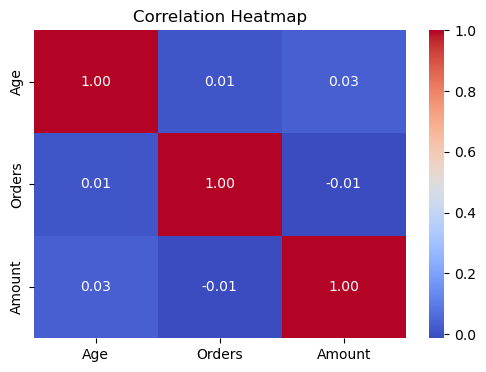

,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,AgeGroup,Purchase_Value_Category
0,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.00,NaN,Adult,High
1,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.00,NaN,Adult,High
2,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.00,NaN,Adult,High
3,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.00,NaN,Minor,High
4,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.00,NaN,Adult,High
5,P00057942,M,26-35,28,1,Himachal Pradesh,Northern,Food Processing,Auto,1,23877.00,NaN,Adult,High
6,P00018042,F,18-25,25,1,Uttar Pradesh,Central,Lawyer,Auto,4,23841.00,NaN,Adult,High
8,P00205642,M,26-35,35,0,Uttar Pradesh,Central,Govt,Auto,2,23809.00,NaN,Adult,High
9,P00031142,F,26-35,26,1,Andhra Pradesh,Southern,Media,Auto,4,23799.99,NaN,Adult,High
10,P00200842,M,26-35,34,0,Delhi,Central,Banking,Auto,1,23770.00,NaN,Adult,High


In [109]:
# 4.2 Correlation Analysis
print("4.2 Correlation Analysis")
# Calculate the pairwise correlations (how much variables move together)
corr_matrix = df[num_cols].corr()
print(corr_matrix)

# Create a visual heatmap of the correlation so it's easy to read for the report
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()
# Show the dataframe state
df.head(10)

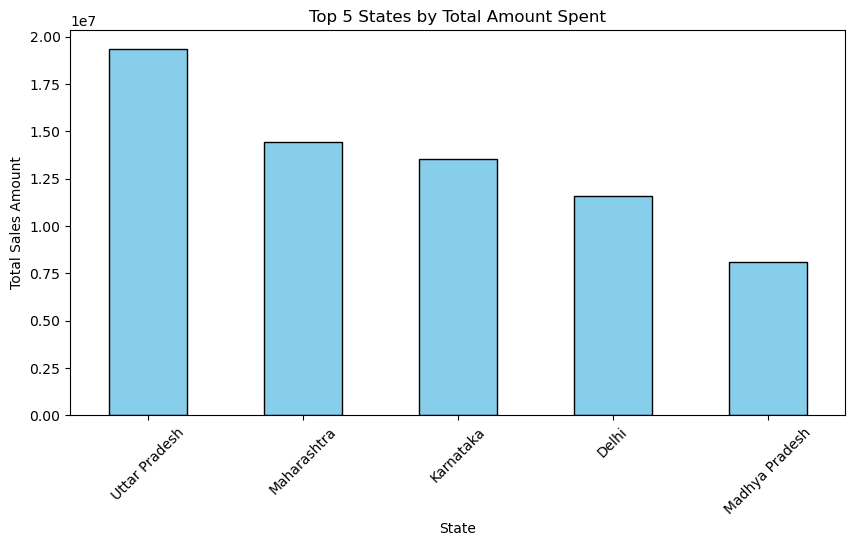

In [110]:
# 5.1.1 Top 5 states by total Amount
# Group by state, add up the amounts, and grab the largest 5
top_states = df.groupby('State')['Amount'].sum().nlargest(5)

plt.figure(figsize=(10, 5))
top_states.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 5 States by Total Amount Spent')
plt.xlabel('State')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.show()

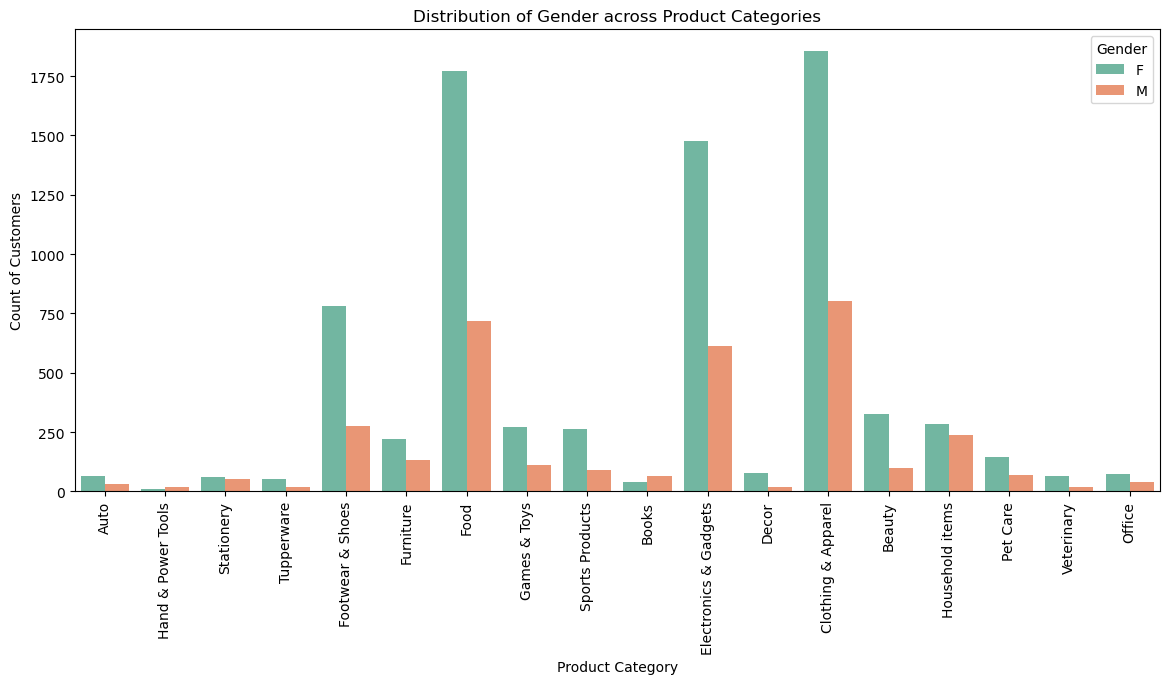

In [111]:
# 5.1.2 Distribution of Gender across Product_Category
plt.figure(figsize=(14, 6))
# countplot automatically counts the number of rows for each category
sns.countplot(data=df, x='Product_Category', hue='Gender', palette='Set2')
plt.title('Distribution of Gender across Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Count of Customers')
plt.xticks(rotation=90) # Rotate text so it doesn't overlap
plt.legend(title='Gender')
plt.show()

/var/folders/wv/n6ftk7ds14bbdpnsvdfzfj300000gn/T/ipykernel_18972/447192719.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_avg_amount = df.groupby('AgeGroup')['Amount'].mean()


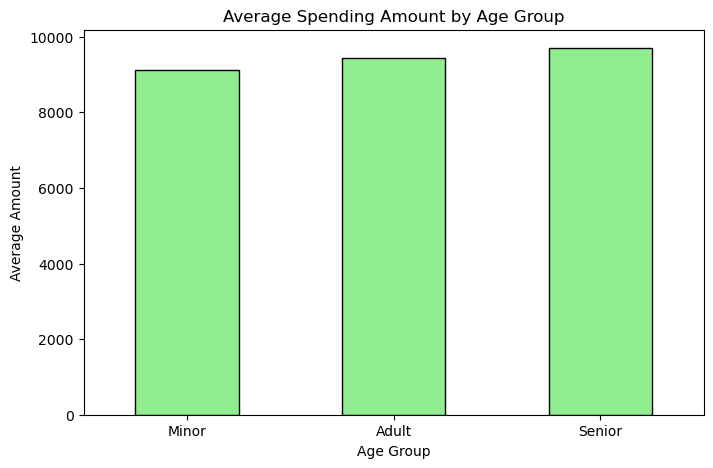

In [112]:
# 5.1.3 Age Group vs Average Amount
# Group by the custom AgeGroup you made in Milestone 1, and find the mean
age_avg_amount = df.groupby('AgeGroup')['Amount'].mean()

plt.figure(figsize=(8, 5))
age_avg_amount.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Average Spending Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Amount')
plt.xticks(rotation=0)
plt.show()

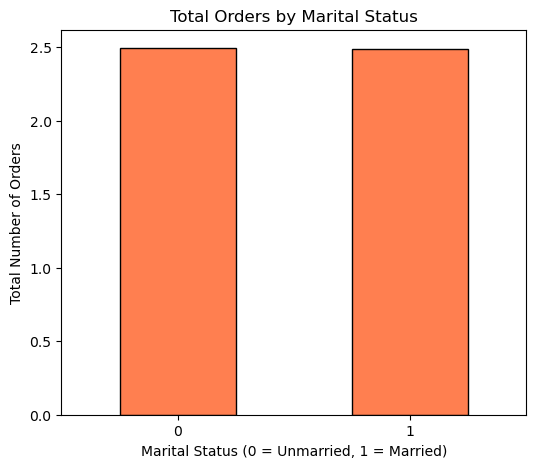

In [ ]:
# 5.1.4 Marital_Status impact on orders
# Let's look at the total number of orders placed by unmarried (0) vs married (1)
marital_orders = df.groupby('Marital_Status')['Orders'].mean()

plt.figure(figsize=(6, 5))
marital_orders.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Total Orders by Marital Status')
plt.xlabel('Marital Status (0 = Unmarried, 1 = Married)')
plt.ylabel('Total Number of Orders')
plt.xticks(rotation=0)
plt.show()

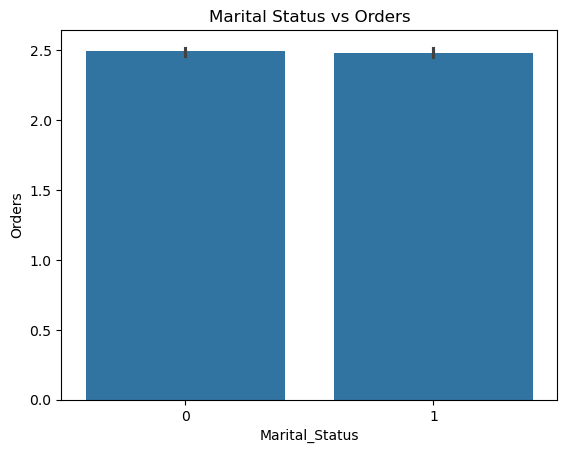

In [114]:
plt.figure()
ax = sns.barplot(data=df, x='Marital_Status', y='Orders')
ax.set_xticks([0, 1])

plt.title("Marital Status vs Orders")
plt.show()

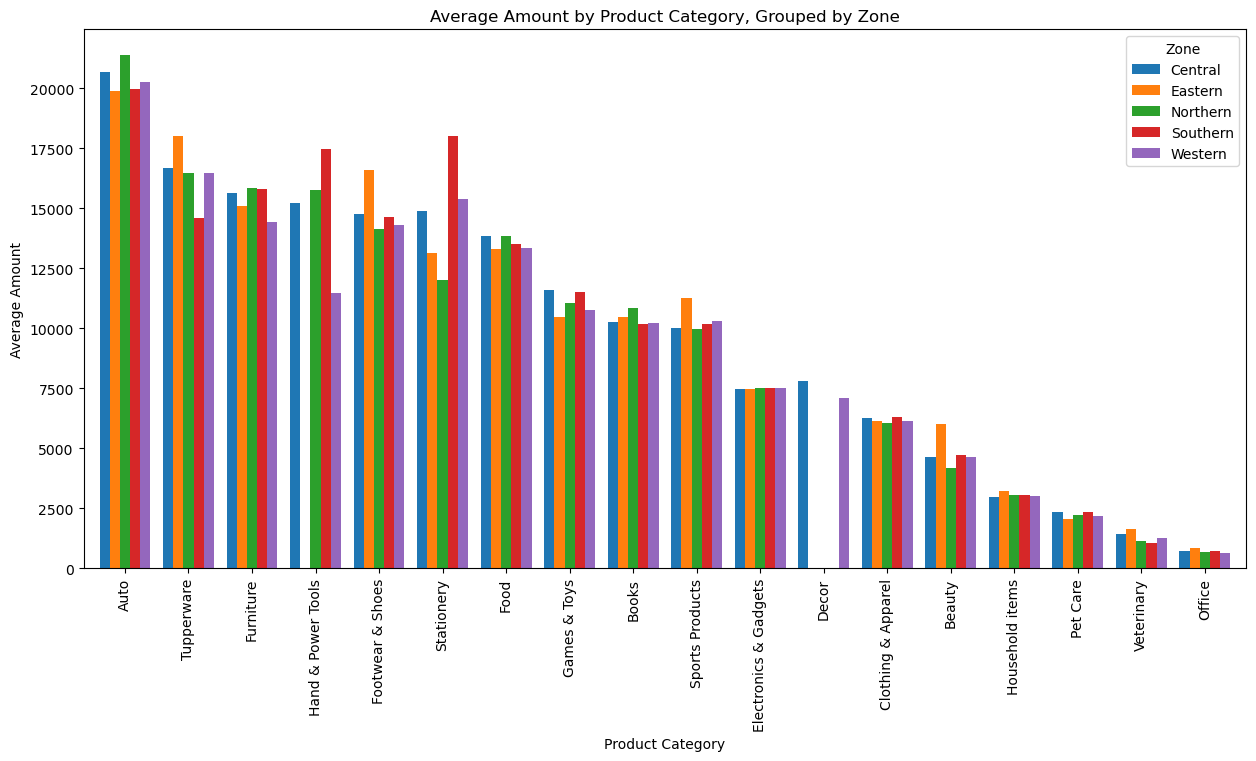

In [115]:
# 5.2 Categorized analysis: Rank product_Category by average Amount, grouped by Zone
pivot_df = df.pivot_table(values='Amount', index='Product_Category', columns='Zone', aggfunc='mean')

# Rank (sort) them by the overall average amount across all zones
pivot_df['Overall_Average'] = pivot_df.mean(axis=1)
pivot_df = pivot_df.sort_values(by='Overall_Average', ascending=False)
pivot_df = pivot_df.drop(columns=['Overall_Average']) # Drop it so it doesn't graph

# Plot the grouped bar chart
pivot_df.plot(kind='bar', figsize=(15, 7), width=0.8)
plt.title('Average Amount by Product Category, Grouped by Zone')
plt.xlabel('Product Category')
plt.ylabel('Average Amount')
plt.xticks(rotation=90)
plt.legend(title='Zone')
plt.show()



In [116]:
# Test 1: Is there a difference in average Amount across Occupation groups?
# H0: Mean Amount is equal across occupations.
# HA: Mean Amount differs significantly.
print("6.1 ANOVA TEST")
# Extract the 'Amount' data for each unique occupation and drop any NaNs
groups = [group['Amount'].dropna() for name, group in df.groupby('Occupation')]

# Run ANOVA test
f_stat, p_value_anova = stats.f_oneway(*groups)

print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_value_anova:.4e}")

if p_value_anova < 0.05:
    print("Conclusion: Reject the Null Hypothesis (H0). There is a significant difference in average Amount across occupations.")
else:
    print("Conclusion: Fail to reject the Null Hypothesis (H0). No significant difference found.")

6.1 ANOVA TEST
F-Statistic: 2.4771
P-Value: 1.6591e-03
Conclusion: Reject the Null Hypothesis (H0). There is a significant difference in average Amount across occupations.


In [117]:
# Test 2: Are Product_Category and Zone independent?
# H0: No Association between category and zone.
# HA: Association exists.
print("6.2 CHI-SQUARE TEST")
# Create a contingency table (a frequency table of categories vs zones)
contingency_table = pd.crosstab(df['Product_Category'], df['Zone'])

# Run the Chi-Square test
chi2, p_value_chi, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p_value_chi:.4e}")
print(f"Degrees of Freedom: {dof}")

if p_value_chi < 0.05:
    print("Conclusion: Reject the Null Hypothesis (H0). There is a significant association between Product Category and Zone.")
else:
    print("Conclusion: Fail to reject the Null Hypothesis (H0). No significant association found.")

6.2 CHI-SQUARE TEST
Chi-Square Statistic: 1634.9669
P-Value: 1.4536e-296
Degrees of Freedom: 68
Conclusion: Reject the Null Hypothesis (H0). There is a significant association between Product Category and Zone.
